# ICA06 — Working with nested and restart simulations 

This notebook is a streamlined introduction to comparing nesting geometries and how to compare simulations when grids differ

Julie.Lundquist@JHU.edu
2026 February (updated from 2023 version)

## Learning goals
By the end, you should be able to:
1. Pick a variable (e.g., PSFC, RAINNC, RAINC)
2. Open one wrfout_d01_... and one wrfout_d02_... at the same valid time
3. Compute the d02 lat/lon bounds; subset d01 to the overlapping region
4. Plot contours of the variable for d01-overlap and d02 side-by-side (common colorbar) to identify the (subtle) differences
5. Pick a point (lat0, lon0) in d02; find nearest gridpoint in each domain
6. Use ncks to extract a time series at that point across all 48 times for d01 and d02
7. Plot the two time series; discuss differences if any

In [11]:

# --- Imports ---
import numpy as np
import pandas as pd
import xarray as xr
import re
from pathlib import Path


import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from pathlib import Path
import glob
import subprocess
import shlex


from matplotlib.axes import Axes # Makes the color bar easier to work with
from mpl_toolkits.axes_grid1 import make_axes_locatable # Color bar location
import matplotlib.ticker as mticker


from matplotlib.colors import ListedColormap, BoundaryNorm # Because I'm particular about color tables
from matplotlib.colors import Normalize # Because I'm particular about color tables
from matplotlib.colors import TwoSlopeNorm # to help normalize map factors so color table is centered on zero



print("Imports OK")

Imports OK


In [12]:
# -------------------------
# STUDENT: edit these
# -------------------------

CASE_DIR = Path("/path/to/your/case")  # folder containing wrfout_d01_* and wrfout_d02_*
CASE_DIR = Path("/scratch/alpine/jlundqui/NWP/ICA06/")

time_str = "2005-08-28_12:00:00"       # pick one valid time string that exists in both domains

varname = "PSFC"   # try: "PSFC", "T2", "U10", "V10"

# point for timeseries (pick a point inside d02)
lat0 = 25.0
lon0 = -88.0


In [20]:
# Find matching d01 and d02 files for a chosen time

d01_file = sorted(CASE_DIR.glob(f"wrfout_d01_*{time_str}*"))
d02_file = sorted(CASE_DIR.glob(f"wrfout_d02_*{time_str}*"))

if len(d01_file) == 0 or len(d02_file) == 0:
    raise FileNotFoundError("Could not find matching wrfout files for the chosen time_str.")

# d01_file = d01_file[0]
# d02_file = d02_file[0]

# print("d01:", d01_file)
# print("d02:", d02_file)
d01_file

[PosixPath('/scratch/alpine/jlundqui/NWP/ICA06/wrfout_d01_2005-08-28_12:00:00')]

In [14]:
# Open the two files with xarray

ds1 = xr.open_dataset(d01_file)
ds2 = xr.open_dataset(d02_file)

# Lat/lon arrays
lat1 = ds1["XLAT"].isel(Time=0)
lon1 = ds1["XLONG"].isel(Time=0)
lat2 = ds2["XLAT"].isel(Time=0)
lon2 = ds2["XLONG"].isel(Time=0)

# bounds of d02 (overlap region)
bounds2 = [float(lon2.min()), float(lon2.max()), float(lat2.min()), float(lat2.max())]
bounds2


[-94.03419494628906,
 -80.45356750488281,
 21.013900756835938,
 31.591703414916992]

In [15]:
# Subset d01 to the d02 overlap region: This uses a mask rather than .sel() since WRF lat/lon are curvilinear.

mask_overlap = (
    (lat1 >= bounds2[2]) & (lat1 <= bounds2[3]) &
    (lon1 >= bounds2[0]) & (lon1 <= bounds2[1])
)

# Extract variable at the chosen time
v1 = ds1[varname].isel(Time=0).where(mask_overlap)
v2 = ds2[varname].isel(Time=0)

# Unit note
print(varname, "units:", ds1[varname].attrs.get("units", "unknown"))


PSFC units: Pa


[OK] Saved figure → PSFC_side_by_side.png


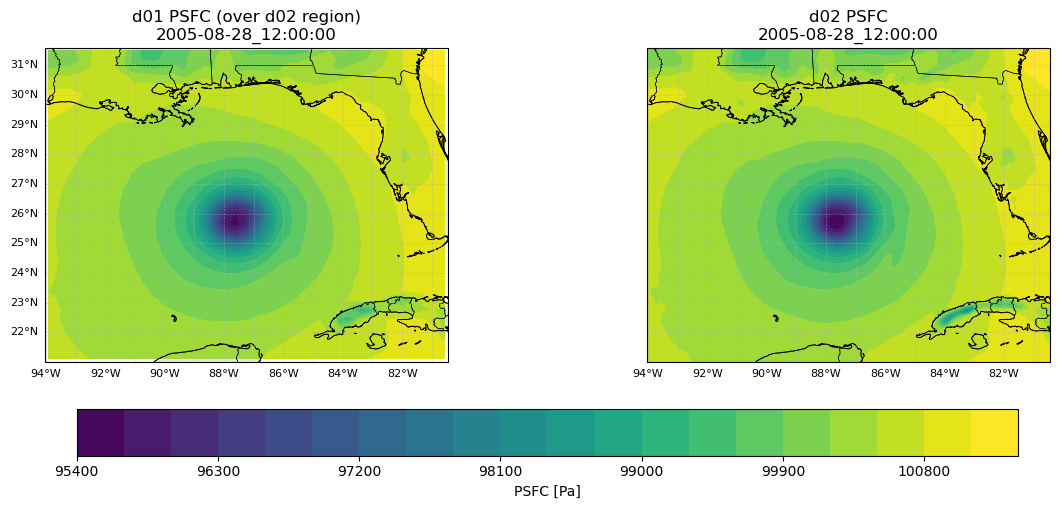

In [7]:
# Plot the two domains side-by-side, only the d02 region for d01

proj = ccrs.PlateCarree()

# common color limits
vmin = float(np.nanmin([v1.min(), v2.min()]))
vmax = float(np.nanmax([v1.max(), v2.max()]))

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

for i, ax in enumerate(axes):

    ax.set_extent(bounds2, crs=proj)

    # Add land and coastlines
    ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

    # Add gridlines with labels
    gl = ax.gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    # Only label left + bottom panels
    gl.top_labels = False
    gl.right_labels = False

    # Only left subplot gets y-labels
    gl.left_labels = (i == 0)

    # Control tick spacing (adjust to taste)
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 1))
    gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 1))

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

# Plot fields
cf1 = axes[0].contourf(
    lon1, lat1, v1,
    levels=20,
    vmin=vmin, vmax=vmax,
    transform=proj
)
axes[0].set_title(f"d01 {varname} (over d02 region)\n{time_str}")

cf2 = axes[1].contourf(
    lon2, lat2, v2,
    levels=20,
    vmin=vmin, vmax=vmax,
    transform=proj
)
axes[1].set_title(f"d02 {varname}\n{time_str}")

# Shared colorbar
cbar = fig.colorbar(cf2, ax=axes, orientation="horizontal", pad=0.08)
cbar.set_label(f"{varname} [{ds1[varname].attrs.get('units','')}]")

save = f"{varname}_side_by_side.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")

plt.show()


In [16]:


def nearest_ij(lat2d, lon2d, lat0, lon0):
    # handle 0..360 lon if present
    lon = lon2d.values
    lat = lat2d.values
    lon0_use = lon0 % 360 if (np.nanmax(lon) > 180 and lon0 < 0) else lon0
    dist2 = (lat - lat0)**2 + (lon - lon0_use)**2
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)
    return int(j), int(i)

j1, i1 = nearest_ij(lat1, lon1, lat0, lon0)
j2, i2 = nearest_ij(lat2, lon2, lat0, lon0)

print("Nearest d01 (j,i):", j1, i1, "lat/lon:", float(lat1[j1,i1]), float(lon1[j1,i1]))
print("Nearest d02 (j,i):", j2, i2, "lat/lon:", float(lat2[j2,i2]), float(lon2[j2,i2]))


Nearest d01 (j,i): 34 51 lat/lon: 24.999998092651367 -87.94633483886719
Nearest d02 (j,i): 37 52 lat/lon: 24.999998092651367 -87.94632720947266


In [42]:
# # Consolidate all the wrfout files into one huge one - probably not helpful unless you want to check out many different variables

# files_d01_str = " ".join(f.name for f in d01_files)
# files_d02_str = " ".join(f.name for f in d02_files)

# cmd_d01 = (
#     f"ncrcat -O {files_d01_str} tmp_d01.nc && "
#     f"ncks -H -C -v {varname} "
#     f"-d south_north,{j1},{j1} "
#     f"-d west_east,{i1},{i1} "
#     f"tmp_d01.nc"
# )

# cmd_d02 = (
#     f"ncrcat -O {files_d02_str} tmp_d02.nc && "
#     f"ncks -H -C -v {varname} "
#     f"-d south_north,{j2},{j2} "
#     f"-d west_east,{i2},{i2} "
#     f"tmp_d02.nc"
# )

# print(cmd_d01)
# print("\n")
# print(cmd_d02)



ncrcat -O wrfout_d01_2005-08-28_00:00:00 wrfout_d01_2005-08-28_01:00:00 wrfout_d01_2005-08-28_02:00:00 wrfout_d01_2005-08-28_03:00:00 wrfout_d01_2005-08-28_04:00:00 wrfout_d01_2005-08-28_05:00:00 wrfout_d01_2005-08-28_06:00:00 wrfout_d01_2005-08-28_07:00:00 wrfout_d01_2005-08-28_08:00:00 wrfout_d01_2005-08-28_09:00:00 wrfout_d01_2005-08-28_10:00:00 wrfout_d01_2005-08-28_11:00:00 wrfout_d01_2005-08-28_12:00:00 wrfout_d01_2005-08-28_13:00:00 wrfout_d01_2005-08-28_14:00:00 wrfout_d01_2005-08-28_15:00:00 wrfout_d01_2005-08-28_16:00:00 wrfout_d01_2005-08-28_17:00:00 wrfout_d01_2005-08-28_18:00:00 wrfout_d01_2005-08-28_19:00:00 wrfout_d01_2005-08-28_20:00:00 wrfout_d01_2005-08-28_21:00:00 wrfout_d01_2005-08-28_22:00:00 wrfout_d01_2005-08-28_23:00:00 wrfout_d01_2005-08-29_00:00:00 wrfout_d01_2005-08-29_01:00:00 wrfout_d01_2005-08-29_02:00:00 wrfout_d01_2005-08-29_03:00:00 wrfout_d01_2005-08-29_04:00:00 wrfout_d01_2005-08-29_05:00:00 wrfout_d01_2005-08-29_06:00:00 wrfout_d01_2005-08-29_07:00:0

In [21]:
# Extract the desired information from a desired location into a small file:

d01_file = sorted(CASE_DIR.glob(f"wrfout_d01_*"))
d02_file = sorted(CASE_DIR.glob(f"wrfout_d02_*"))


def build_fix2_commands(file_list, varname, j, i, tag):
    """
    Build a 3-line Fix-2 command sequence:
      1) ncrcat only varname to a small tmp file
      2) ncks subset to a single grid point into final file
      3) rm tmp file

    Parameters
    ----------
    file_list : list[Path]
        wrfout files (Paths). We'll use f.name so scripts are portable.
    varname : str
        Variable to extract (e.g., "PSFC", "RAINNC").
    j, i : int
        Indices in WRF dims south_north, west_east.
    tag : str
        "d01" or "d02" for output naming.

    Returns
    -------
    str
        Multi-line bash snippet.
    """
    files_str = " ".join(f.name for f in file_list)

    tmp_nc = f"tmp_{varname}_{tag}.nc"
    out_nc = f"{varname}_{tag}.nc"

    cmd1 = f"ncrcat -O -v {varname} {files_str} {tmp_nc}"
    cmd2 = (
        f"ncks -O -v {varname} "
        f"-d south_north,{j},{j} "
        f"-d west_east,{i},{i} "
        f"{tmp_nc} {out_nc}"
    )
    cmd3 = f"rm -f {tmp_nc}"

    return "\n".join([cmd1, cmd2, cmd3])


# Example usage (assuming you already have these):
# d01_files, d02_files = [...]
# varname = "PSFC"
# j1,i1 = 34,51
# j2,i2 = 37,52

snippet_d01 = build_fix2_commands(d01_file, varname, j1, i1, tag="d01")
snippet_d02 = build_fix2_commands(d02_file, varname, j2, i2, tag="d02")

print("### d01 ###")
print(snippet_d01)
print("\n### d02 ###")
print(snippet_d02)


### d01 ###
ncrcat -O -v PSFC wrfout_d01_2005-08-28_00:00:00 wrfout_d01_2005-08-28_01:00:00 wrfout_d01_2005-08-28_02:00:00 wrfout_d01_2005-08-28_03:00:00 wrfout_d01_2005-08-28_04:00:00 wrfout_d01_2005-08-28_05:00:00 wrfout_d01_2005-08-28_06:00:00 wrfout_d01_2005-08-28_07:00:00 wrfout_d01_2005-08-28_08:00:00 wrfout_d01_2005-08-28_09:00:00 wrfout_d01_2005-08-28_10:00:00 wrfout_d01_2005-08-28_11:00:00 wrfout_d01_2005-08-28_12:00:00 wrfout_d01_2005-08-28_13:00:00 wrfout_d01_2005-08-28_14:00:00 wrfout_d01_2005-08-28_15:00:00 wrfout_d01_2005-08-28_16:00:00 wrfout_d01_2005-08-28_17:00:00 wrfout_d01_2005-08-28_18:00:00 wrfout_d01_2005-08-28_19:00:00 wrfout_d01_2005-08-28_20:00:00 wrfout_d01_2005-08-28_21:00:00 wrfout_d01_2005-08-28_22:00:00 wrfout_d01_2005-08-28_23:00:00 wrfout_d01_2005-08-29_00:00:00 wrfout_d01_2005-08-29_01:00:00 wrfout_d01_2005-08-29_02:00:00 wrfout_d01_2005-08-29_03:00:00 wrfout_d01_2005-08-29_04:00:00 wrfout_d01_2005-08-29_05:00:00 wrfout_d01_2005-08-29_06:00:00 wrfout_d0

In [54]:
# After you run those commands on derecho in the directory where your files are, bring them over here

d01_file = sorted(CASE_DIR.glob(f"{varname}_d01.nc"))
d02_file = sorted(CASE_DIR.glob(f"{varname}_d02.nc"))

ds_d01 = xr.open_dataset(d01_file[0])
ds_d02 = xr.open_dataset(d02_file[0])

ds_d02["XTIME"]

<xarray.DataArray 'XTIME' (Time: 49)>
array(['2005-08-28T00:00:00.000000000', '2005-08-28T01:00:00.000000000',
       '2005-08-28T02:00:00.000000000', '2005-08-28T03:00:00.000000000',
       '2005-08-28T04:00:00.000000000', '2005-08-28T05:00:00.000000000',
       '2005-08-28T06:00:00.000000000', '2005-08-28T07:00:00.000000000',
       '2005-08-28T08:00:00.000000000', '2005-08-28T09:00:00.000000000',
       '2005-08-28T10:00:00.000000000', '2005-08-28T11:00:00.000000000',
       '2005-08-28T12:00:00.000000000', '2005-08-28T13:00:00.000000000',
       '2005-08-28T14:00:00.000000000', '2005-08-28T15:00:00.000000000',
       '2005-08-28T16:00:00.000000000', '2005-08-28T17:00:00.000000000',
       '2005-08-28T18:00:00.000000000', '2005-08-28T19:00:00.000000000',
       '2005-08-28T20:00:00.000000000', '2005-08-28T21:00:00.000000000',
       '2005-08-28T22:00:00.000000000', '2005-08-28T23:00:00.000000000',
       '2005-08-29T00:00:00.000000000', '2005-08-29T01:00:00.000000000',
       '2005-08-29T02:00:00.000000000', '2005-08-29T03:00:00.000000000',
       '2005-08-29T04:00:00.000000000', '2005-08-29T05:00:00.000000000',
       '2005-08-29T06:00:00.000000000', '2005-08-29T07:00:00.000000000',
       '2005-08-29T08:00:00.000000000', '2005-08-29T09:00:00.000000000',
       '2005-08-29T10:00:00.000000000', '2005-08-29T11:00:00.000000000',
       '2005-08-29T12:00:00.000000000', '2005-08-29T13:00:00.000000000',
       '2005-08-29T14:00:00.000000000', '2005-08-29T15:00:00.000000000',
       '2005-08-29T16:00:00.000000000', '2005-08-29T17:00:00.000000000',
       '2005-08-29T18:00:00.000000000', '2005-08-29T19:00:00.000000000',
       '2005-08-29T20:00:00.000000000', '2005-08-29T21:00:00.000000000',
       '2005-08-29T22:00:00.000000000', '2005-08-29T23:00:00.000000000',
       '2005-08-30T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
    XTIME    (Time) datetime64[ns] 2005-08-28 2005-08-28T01:00:00 ... 2005-08-30
Dimensions without coordinates: Time
Attributes:
    FieldType:    104
    MemoryOrder:  0  
    description:  minutes since 2005-08-28 00:00:00
    stagger:

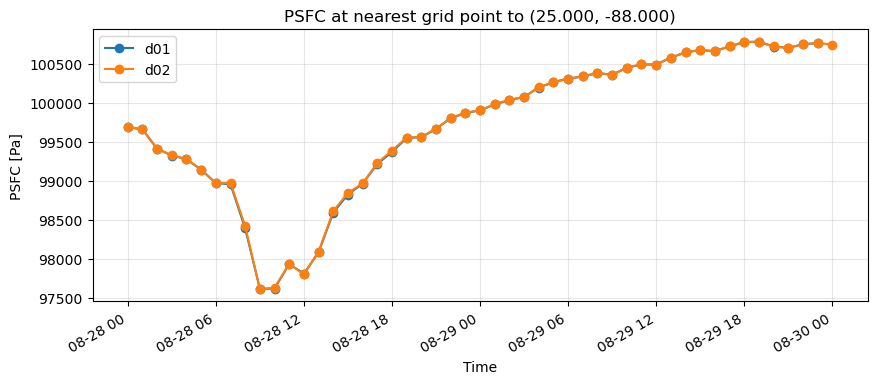

In [57]:
# Plot the time series - clean it first b/c Julie's simulation ended up with one file with many duplicate times

def clean_timeseries(t, y):
    """
    Return (t_clean, y_clean) with:
      - NaNs removed
      - time sorted
      - duplicate times dropped (keep first occurrence)
    """
    df = pd.DataFrame({"time": pd.to_datetime(t), "y": np.asarray(y)})
    df = df.dropna(subset=["time", "y"]).sort_values("time")
    df = df.drop_duplicates(subset="time", keep="first")
    return df["time"].values, df["y"].values

# --- extract raw series (adjust indexing to your case) ---
t1 = ds_d01["XTIME"].values
y1 = ds_d01[varname].isel(south_north=0, west_east=0).values # 0 b/c we've already subsetted

t2 = ds_d02["XTIME"].values
y2 = ds_d02[varname].isel(south_north=0, west_east=0).values

# --- clean ---
t1c, y1c = clean_timeseries(t1, y1)
t2c, y2c = clean_timeseries(t2, y2)

# --- plot ---
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(t1c, y1c, marker="o", label="d01")
ax.plot(t2c, y2c, marker="o", label="d02")

ax.set_title(f"{varname} at nearest grid point to ({lat0:.3f}, {lon0:.3f})")
ax.set_xlabel("Time")
ax.set_ylabel(f"{varname} [{ds_d01[varname].attrs.get('units','')}]")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.show()


# t1 = ds_d01["XTIME"].values
# t2 = ds_d02["XTIME"].values


# # y1 = ds_d01[varname].isel(south_north=j1, west_east=i1).values
# # y2 = ds_d02[varname].isel(south_north=j2, west_east=i2).values
# y1 = ds_d01[varname].isel(south_north=0, west_east=0).values # we already selected when we did the ncks step
# y2 = ds_d02[varname].isel(south_north=0, west_east=0).values # we already selected when we did the ncks step


# fig, ax = plt.subplots(figsize=(10,4))
# ax.plot(t1, y1, marker="o", label="d01")
# ax.plot(t2, y2, marker="o", label="d02")

# ax.set_title(f"{varname} at nearest grid point to ({lat0:.3f}, {lon0:.3f})")
# ax.set_xlabel("Time")
# ax.set_ylabel(f"{varname} [{ds_d01[varname].attrs.get('units','')}]")
# ax.grid(True, alpha=0.3)
# ax.legend()
# fig.autofmt_xdate()
# plt.show()
